**PHASE 5: SENTIMENT ANALYSIS**

Imports for Sentiment Analysis

In [1]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer # for VADER (for sentiment analysis) 
import nltk # for NLP tools (tokenization, lexicons) 
import pandas as pd # for handling df (dataframes) 
import re # for regular expression
import numpy as np # for handling numerical operations
import spacy # spaCy for NLP & parsing
from nltk.tokenize import sent_tokenize, word_tokenize # sentence and word tokenizors

nltk.download('punkt') # download tokenizor models
nltk.download('vader_lexicon') # download VADER lexicon for sentiment scoring

# initialize analyzer
analyzer = SentimentIntensityAnalyzer() # create VADER sentiment analyzer object
nlp = spacy.load("en_core_web_sm") # load small spaCy English model

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\JulianYip\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\JulianYip\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


**5.1 - Document-Level Sentiment Analysis**

In [ ]:
# Load preprocessed dataset
combined_df = pd.read_csv('combined_reviews.csv')

# Define a safe function for handling sentiment scoring
def get_vader_scores(text):
    if pd.isna(text):  # if review is missing
        return pd.Series({'neg': np.nan, 'neu': np.nan, 'pos': np.nan, 'compound': np.nan}) # returns NaN for each column
    else: # if text exists
        scores = analyzer.polarity_scores(str(text))
        return pd.Series(scores)

# Apply to cleaned_review_text column
combined_df[['neg', 'neu', 'pos', 'compound']] = combined_df['cleaned_review_text'].apply(get_vader_scores)

# Define sentiment label function based on compound score
def get_sentiment_label(score):
    if pd.isna(score):
        return np.nan
    elif score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

# Apply to get sentiment_label
combined_df['sentiment_label'] = combined_df['compound'].apply(get_sentiment_label)

# show the first 5 rows of the sentiment columns
combined_df[['compound', 'pos', 'neu', 'neg']].head()


,compound,pos,neu,neg
0,-0.8047,0.194,0.515,0.291
1,0.9773,0.609,0.391,0.000
2,0.9950,0.453,0.522,0.025
3,-0.5003,0.119,0.749,0.132
4,-0.8979,0.044,0.748,0.208


**5.2 - Aspect Based Sentiment Analysis (ABSA)**

1. Extracting Aspect-Based Sentiment Scores
- uses spaCy to look for the words (looks at the "children" & "neighbour" to the adjective)
- VADER just for assigning scores

In [ ]:
# possible words in each rating aspect
aspects = {
    "seat": ["seat", "seating", "seatbelt", "legroom"],
    "staff": ["staff", "crew", "attendant", "service"],
    "food": ["food", "meal", "breakfast", "lunch", "dinner", "snack"],
    "entertainment": ["entertainment", "screen", "movies", "ife"],
    "ground": ["ground", "checkin", "airport", "baggage", "luggage"],
    "wifi": ["wifi", "internet", "connectivity"],
    "value": ["value", "price", "worth", "money"]
}

def absa_spacy(review):
    # creates absa columns for each aspect
    results = {f"absa_{a}": 0.0 for a in aspects.keys()}

    if pd.isna(review):
        return pd.Series(results)

    doc = nlp(str(review))  # spaCy to analyze grammar and review structure

    # storing descriptive words for each topic in a list
    aspect_phrases = {a: [] for a in aspects.keys()}

    # finding matches from "aspects" on each review
    for token in doc:
        token_lemma = token.lemma_.lower() # get the root form of word (seats -> seat)
        for aspect, keywords in aspects.items(): # look for the word from the aspects
            if token_lemma in keywords:

                # look for grammar dependency
                # E.g.: "food was cold", where "cold" is the child of "food"
                for child in token.children:
                    # (amod = adjective) (acomp = adjectival complement) (advmod = adverbial modifier)
                    # (cold) -> (after verb "is", "was") -> ("badly", "very")
                    if child.dep_ in ("amod", "acomp", "advmod"): 
                        aspect_phrases[aspect].append(child.text) # save child word to text
                
                # checks for previous neighbour 
                # E.g.: "tasty meal", where "tasty" is neighbour before "meal" 
                prev = token.nbor(-1) if token.i > 0 else None

                # if there is a neghbour and is adjective
                if prev is not None and prev.pos_ == "ADJ":
                    aspect_phrases[aspect].append(prev.text) # save adjective to previous text
            
                # look for whole sentence (broad search)
                # look for adjective within the sentence
                for tok in token.sent:
                    if tok.pos_ == "ADJ":
                        # stores short phrases to the list
                        aspect_phrases[aspect].append(tok.text)

    # implement VADER for scoring
    for aspect in aspects.keys():
        phrases = [p for p in aspect_phrases[aspect] if isinstance(p, str) and p.strip() != ""] # to ensure that only have strings
        if len(phrases) == 0: # if no words found, give it 0
            results[f"absa_{aspect}"] = 0.0
        else: # use VADER to get score for each word
            scores = [analyzer.polarity_scores(p)["compound"] for p in phrases]  # analyzer to determine pos, neu, neg
            results[f"absa_{aspect}"] = float(sum(scores) / len(scores))

    return pd.Series(results)

combined_df[[f"absa_{a}" for a in aspects.keys()]] = combined_df["review_text"].apply(absa_spacy)

combined_df.to_csv('combined_with_sentiment.csv', index=False, na_rep='NaN')


2. Visualizing Aspect-Based Sentiment Insights

C:\Users\JulianYip\AppData\Local\Temp\ipykernel_26808\3761066200.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_scores.values, y=[l.replace('absa_', '').title() for l in avg_scores.index], palette=colors)


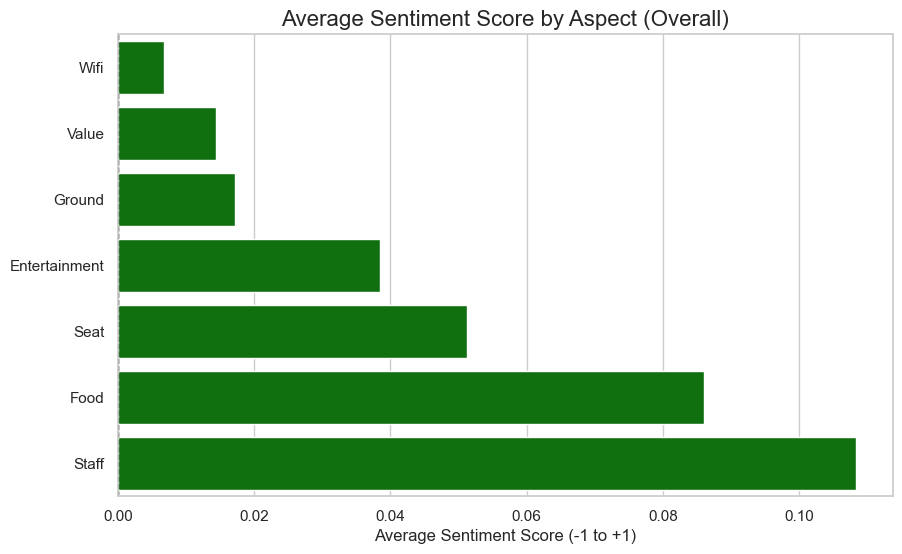

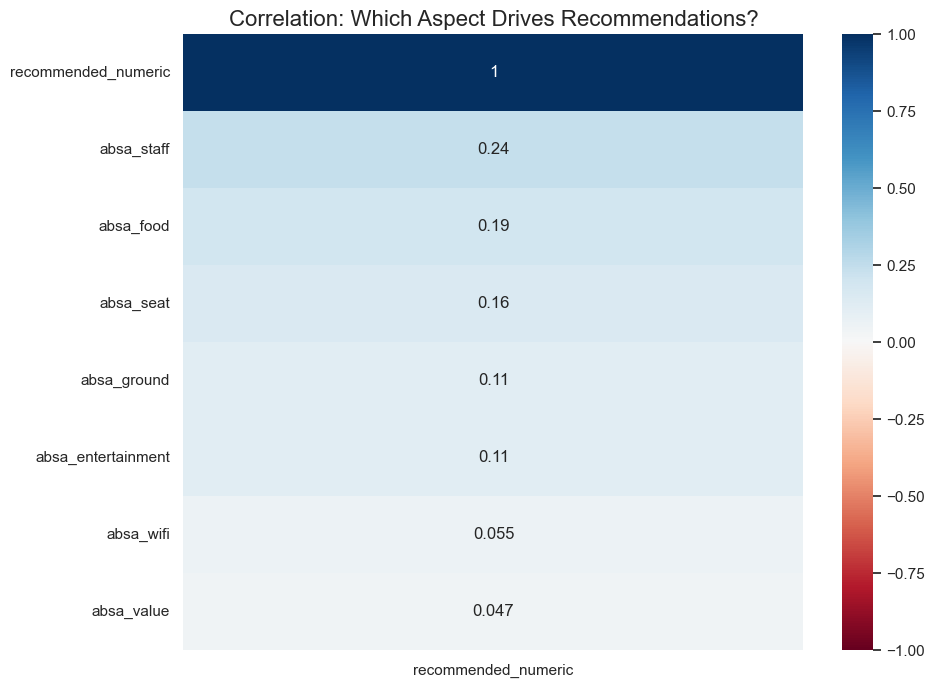

C:\Users\JulianYip\AppData\Local\Temp\ipykernel_26808\3761066200.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=mentions_only, y='aspect',


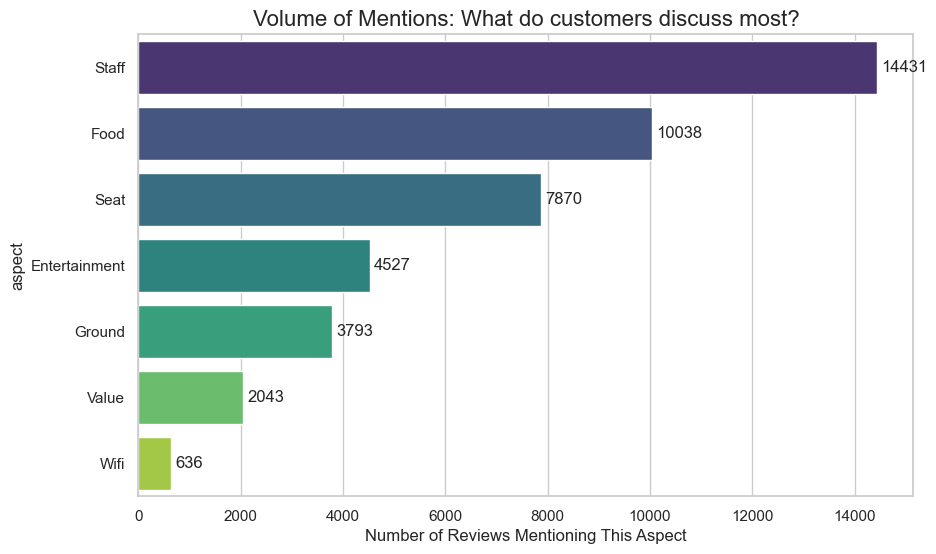

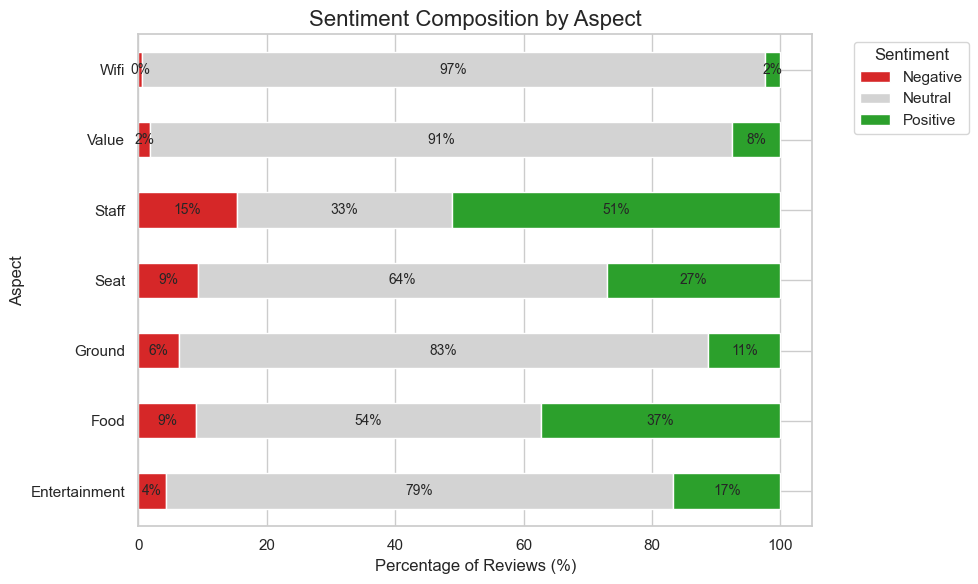

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data
df = pd.read_csv('combined_with_sentiment.csv') 

# Define absa columns
absa_cols = ['absa_seat', 'absa_staff', 'absa_food', 'absa_entertainment', 
             'absa_ground', 'absa_wifi', 'absa_value']

# Clean up column names for nicer labels
clean_labels = [col.replace('absa_', '').title() for col in absa_cols]

# Set the visual style
sns.set_theme(style="whitegrid")

# ==========================================
# PLOT 1: AVERAGE SENTIMENT 
# ==========================================
plt.figure(figsize=(10, 6))
avg_scores = df[absa_cols].mean().sort_values() 

# Create bar chart
colors = ['red' if x < 0 else 'green' for x in avg_scores]
sns.barplot(x=avg_scores.values, y=[l.replace('absa_', '').title() for l in avg_scores.index], palette=colors)

plt.title('Average Sentiment Score by Aspect (Overall)', fontsize=16)
plt.xlabel('Average Sentiment Score (-1 to +1)')
plt.axvline(0, color='black', linestyle='--', linewidth=1) 
plt.show()

# ==========================================
# PLOT 2: CORRELATION HEATMAP 
# ==========================================
# Convert no/yes to 0/1 (using lambda)
df['recommended_numeric'] = df['recommended'].apply(lambda x: 1 if str(x).lower() in ['yes', 'true', '1', 'recommended'] else 0)

corr_data = df[absa_cols + ['recommended_numeric']] # create subset data
correlation = corr_data.corr() # measures the correlation between recommended

plt.figure(figsize=(10, 8))
sns.heatmap(correlation[['recommended_numeric']].sort_values(by='recommended_numeric', ascending=False), 
            annot=True, cmap='RdBu', vmin=-1, vmax=1)
plt.title('Correlation: Which Aspect Drives Recommendations?', fontsize=16)
plt.show()

# ==========================================
# PLOT 3: FREQUENCY CHART
# ==========================================
# categorize scores
def categorize_sentiment(score):
    if score > 0.01: return 'Positive'
    if score < -0.01: return 'Negative'
    return 'Neutral'

# Prepare data for plotting
plot_df = pd.DataFrame()
for col in absa_cols:
    temp = df[[col]].copy()
    temp.columns = ['score']
    temp['aspect'] = col.replace('absa_', '').title()
    temp['sentiment_category'] = temp['score'].apply(categorize_sentiment)
    plot_df = pd.concat([plot_df, temp])

plt.figure(figsize=(10, 6))
# Filter out 'Neutral' (0.0) 
mentions_only = plot_df[plot_df['sentiment_category'] != 'Neutral']

# Save the plot to a variable 'ax' for modification
ax = sns.countplot(data=mentions_only, y='aspect', 
              order=mentions_only['aspect'].value_counts().index, 
              palette='viridis')


# For adding labels to each bars
for container in ax.containers:
    ax.bar_label(container, padding=3)  # padding=3 moves the text slightly right

plt.title('Volume of Mentions: What do customers discuss most?', fontsize=16)
plt.xlabel('Number of Reviews Mentioning This Aspect')
plt.show()

# ==========================================
# PLOT 4: SENTIMENT COMPOSITION (Stacked Chart)
# ==========================================
# Calculate percentages
sentiment_counts = (plot_df.groupby(['aspect', 'sentiment_category'])
                    .size()
                    .unstack(fill_value=0))

# Convert to percentage
sentiment_pct = sentiment_counts.div(sentiment_counts.sum(axis=1), axis=0) * 100

# Reorder columns for logical flow
sentiment_pct = sentiment_pct[['Negative', 'Neutral', 'Positive']]

# Plot
# Assign the plot to 'ax' so we can add labels to it
ax = sentiment_pct.plot(kind='barh', stacked=True, 
                        color=['#d62728', '#d3d3d3', '#2ca02c'], 
                        figsize=(10, 6))

# --- ADD PERCENTAGE LABELS ---
# Loop through each segment (Negative, Neutral, Positive)
for c in ax.containers:
    # custom label formatting: only show label if value > 0
    labels = [f'{v.get_width():.0f}%' if v.get_width() > 0 else '' for v in c]
    
    # Add the labels to the center of the bars
    ax.bar_label(c, labels=labels, label_type='center', fontsize=10)

plt.title('Sentiment Composition by Aspect', fontsize=16)
plt.xlabel('Percentage of Reviews (%)')
plt.ylabel('Aspect')
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**PHASE 6: TF-IDF FEATURE EXTRACTION**

- stands for Term Frequency-Inverse Document Frequency
- TF(frequency of word) * IDF (how rare the word is in the document)
- convert unstructured text into numerical vectors that ML algorithms can read

In [ ]:
import pandas as pd # structuring data frame
import numpy as np # numerical operations
from sklearn.feature_extraction.text import TfidfVectorizer # convert text features to numerical features
from sklearn.model_selection import train_test_split # split dataset 
from scipy.sparse import hstack # combining text vectors
from imblearn.over_sampling import SMOTE # SMOTE to tackle class imbalance
import pickle # exporting pickle file

df = pd.read_csv('combined_with_sentiment.csv')

# Ensure target variable is string 
df['recommended'] = df['recommended'].astype(str)

# Fill missing review text to prevent crash
df['cleaned_review_text'] = df['cleaned_review_text'].fillna('') # empty string

# X is a hybrid of text features from TF-IDF & sentiment columns 
# Y is recommended column (yes/no)

# Text + Target Variable
X_text = df['cleaned_review_text']
y = df['recommended']

# Numeric columns
numeric_cols = [
    'neg', 'neu', 'pos', 'compound',
]

# Fill numeric missing
df[numeric_cols] = df[numeric_cols].fillna(0)

X_numeric = df[numeric_cols] # creates dataframe for sentiment columns

# Split — correct order
X_text_train, X_text_test, X_num_train, X_num_test, y_train, y_test = train_test_split(
    X_text, # claned review text
    X_numeric, # cleaned sentiment scores
    y, # target variable
    test_size=0.2, # 20% for test, 80% for train
    random_state=42, # makes the result consistent (gets same data, if not randomises)
    stratify=y # ensuring "yes" / "no" consistent
)

# ensure string format 
y_train = y_train.astype(str)
y_test = y_test.astype(str)

# TF-IDF (fit on train only)
tfidf = TfidfVectorizer(
    max_features=20000, #20000 featyres
    ngram_range=(1,3), # detect trigrams
    stop_words='english' # remove stopwords
)

# learns vocab from trained data then convert to number (take it as revising)
X_train_tfidf = tfidf.fit_transform(X_text_train) 
# takes what it learnt from training, apply to test (take it as an exam)
X_test_tfidf = tfidf.transform(X_text_test)

# Combine text + numeric into one matrix
# Stacks TF-IDF text numbers with sentiment scores
X_train = hstack([X_train_tfidf, X_num_train.values])
X_test = hstack([X_test_tfidf, X_num_test.values])

# APPLY SMOTE (only on training) 
sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

print("After SMOTE class distribution:\n")
print(y_train.value_counts())

# Save final output
with open('tfidf_split.pkl', 'wb') as f:
    pickle.dump((X_train, X_test, y_train, y_test, tfidf, numeric_cols), f)

print("Shapes:")
print("Train:", X_train.shape)
print("Test :", X_test.shape)
print("\nTrain class distribution:\n", y_train.value_counts())
print("\nTest class distribution:\n", y_test.value_counts())


After SMOTE class distribution:

recommended
yes    13554
no     13554
Name: count, dtype: int64
Shapes:
Train: (27108, 20004)
Test : (4338, 20004)

Train class distribution:
 recommended
yes    13554
no     13554
Name: count, dtype: int64

Test class distribution:
 recommended
no     3389
yes     949
Name: count, dtype: int64
